# Job Market — Python Analytics

Covers: **EDA · Trend Analysis · Correlation · NLP Skill Extraction · Salary Forecasting · Skill Clustering**

Data source: `combined_jobs_data.db` (SQLite) — the same cleaned tables used in the earlier SQL analytics pass
(`clean_salaries`, `clean_cleaned_data_analyst_jobs`, `clean_jobs_cleaned_table`, `clean_data_analyst_raw`, plus the
skill/category lookup tables). Place this notebook in the same folder as `combined_jobs_data.db` to run it.

In [1]:
%matplotlib inline
import sqlite3
import re
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 50)

DB_PATH = "combined_jobs_data.db"
con = sqlite3.connect(DB_PATH)

def q(sql):
    return pd.read_sql(sql, con)

[t[0] for t in con.execute("SELECT name FROM sqlite_master WHERE type='table' ORDER BY 1").fetchall()]

['ai_impact_on_jobs',
 'ai_job_market_insights',
 'ai_job_market_insights_dup',
 'categories_hoja1',
 'clean_ai_impact_on_jobs',
 'clean_ai_job_market_insights',
 'clean_ai_job_market_insights_dup',
 'clean_cleaned_data_analyst_jobs',
 'clean_data_analyst_raw',
 'clean_jobs_cleaned_table',
 'clean_jobs_raw_table',
 'clean_salaries',
 'cleaned_data_analyst_jobs',
 'country_salary',
 'data_analyst_raw',
 'experience_salary',
 'job_industries',
 'job_skills',
 'jobs_cleaned_table',
 'jobs_raw_table',
 'profile_hoja1',
 'remote_trends',
 'salaries',
 'salary_trends',
 'skills_hoja1',
 'skills_lookup',
 'skills_skills',
 'states_hoja1']

In [2]:
# Core tables used throughout this notebook
salaries   = q("SELECT * FROM clean_salaries")
analyst    = q("SELECT * FROM clean_cleaned_data_analyst_jobs")
jobs_clean = q("SELECT * FROM clean_jobs_cleaned_table")
skills_vocab = pd.concat([q("SELECT * FROM skills_skills"), q("SELECT * FROM skills_hoja1")], ignore_index=True).dropna()

print("salaries:", salaries.shape)
print("analyst (Glassdoor Data Analyst postings):", analyst.shape)
print("jobs_clean (Indeed scrape):", jobs_clean.shape)
print("skills_vocab (skill dictionary):", skills_vocab.shape)

salaries: (71913, 14)
analyst (Glassdoor Data Analyst postings): (2252, 24)
jobs_clean (Indeed scrape): (2919, 27)
skills_vocab (skill dictionary): (177, 2)


## 1. Exploratory Data Analysis (EDA)

Quick shape check, missingness, and the core distributions we'll build everything else on top of.

In [3]:
salaries.info()

<class 'pandas.DataFrame'>
RangeIndex: 71913 entries, 0 to 71912
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   work_year           71913 non-null  int64
 1   experience_level    71913 non-null  str  
 2   employment_type     71913 non-null  str  
 3   job_title           71913 non-null  str  
 4   salary              71913 non-null  int64
 5   salary_currency     71913 non-null  str  
 6   salary_in_usd       71913 non-null  int64
 7   employee_residence  71913 non-null  str  
 8   remote_ratio        71913 non-null  int64
 9   company_location    71913 non-null  str  
 10  company_size        71913 non-null  str  
 11  possible_duplicate  71913 non-null  int64
 12  title_clean         71913 non-null  str  
 13  title_category      71913 non-null  str  
dtypes: int64(5), str(9)
memory usage: 7.7 MB


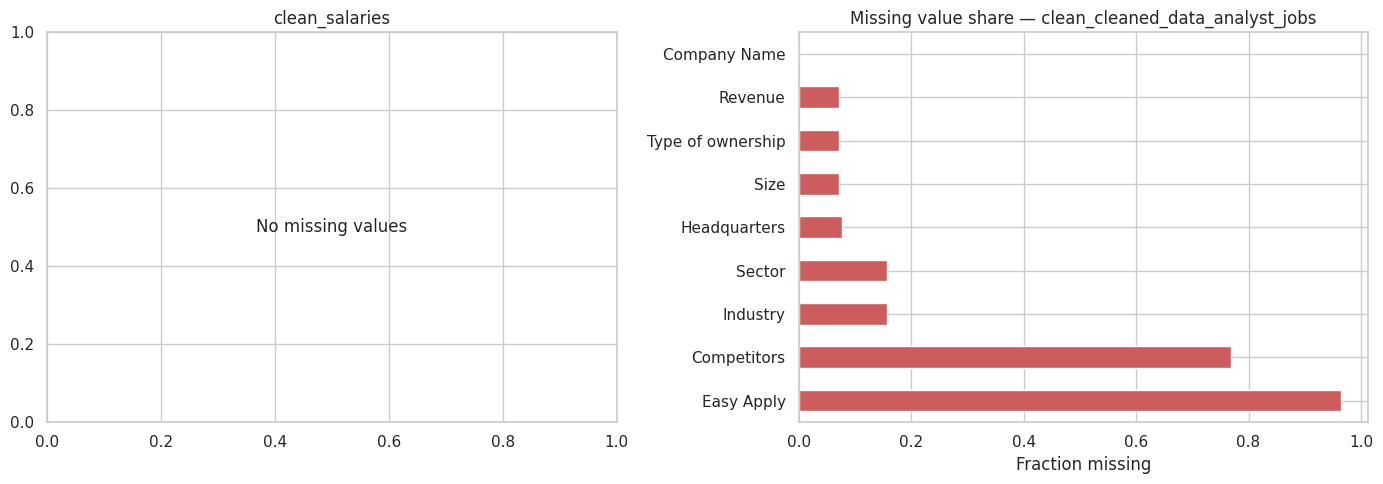

In [4]:
# Missingness across the two main job tables
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, df, name in zip(axes, [salaries, analyst], ["clean_salaries", "clean_cleaned_data_analyst_jobs"]):
    miss = df.isna().mean().sort_values(ascending=False)
    miss = miss[miss > 0]
    if len(miss) == 0:
        ax.text(0.5, 0.5, "No missing values", ha="center", va="center")
        ax.set_title(name)
        continue
    miss.plot(kind="barh", ax=ax, color="indianred")
    ax.set_title(f"Missing value share — {name}")
    ax.set_xlabel("Fraction missing")
plt.tight_layout()
plt.show()

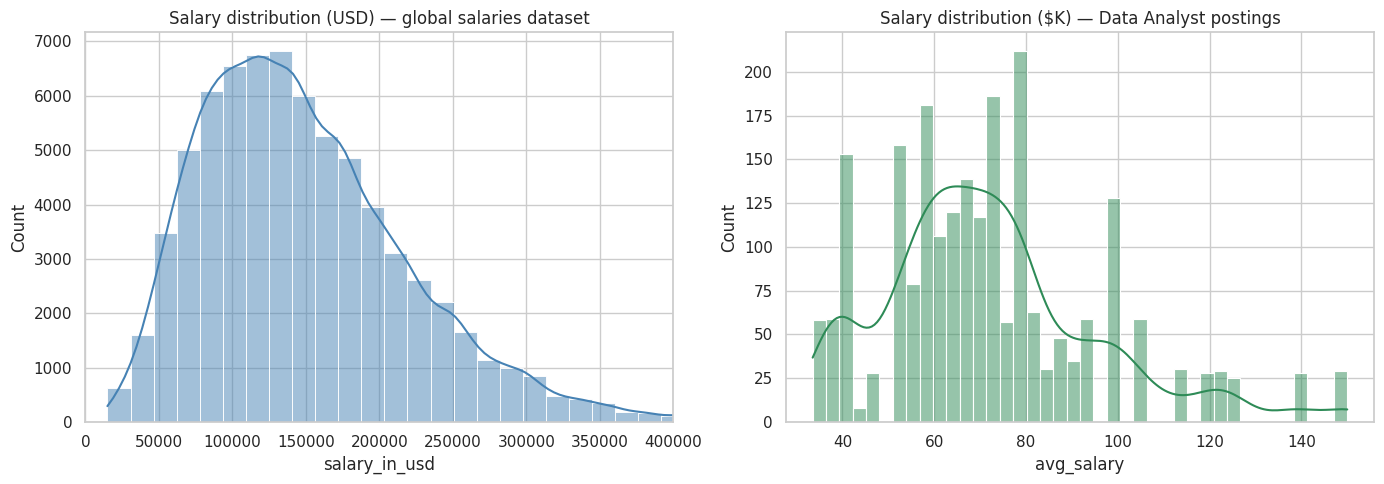

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(salaries["salary_in_usd"], bins=50, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Salary distribution (USD) — global salaries dataset")
axes[0].set_xlim(0, 400000)

sns.histplot(analyst["avg_salary"], bins=40, kde=True, ax=axes[1], color="seagreen")
axes[1].set_title("Salary distribution ($K) — Data Analyst postings")
plt.tight_layout()
plt.show()

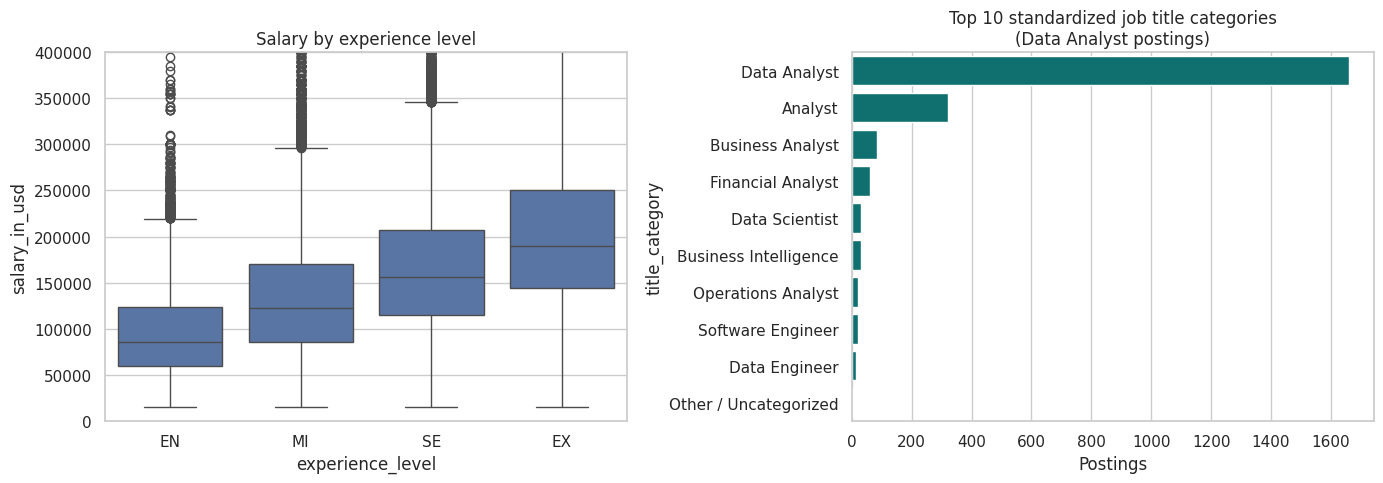

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order = ["EN", "MI", "SE", "EX"]
sns.boxplot(data=salaries, x="experience_level", y="salary_in_usd", order=order, ax=axes[0])
axes[0].set_title("Salary by experience level")
axes[0].set_ylim(0, 400000)

top_titles = analyst["title_category"].value_counts().head(10)
sns.barplot(x=top_titles.values, y=top_titles.index, ax=axes[1], color="teal")
axes[1].set_title("Top 10 standardized job title categories\n(Data Analyst postings)")
axes[1].set_xlabel("Postings")
plt.tight_layout()
plt.show()

## 2. Trend Analysis

`clean_salaries` spans **2020–2025**, the only real time series in the combined data — used here to track posting
volume, average pay, and remote-work mix over time.

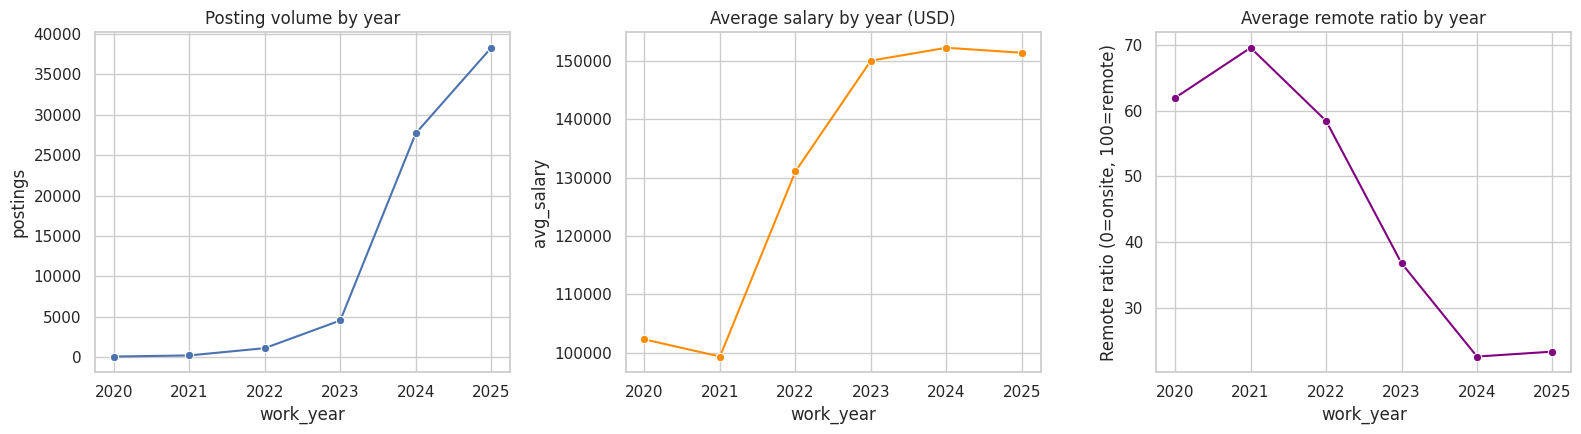

,work_year,postings,avg_salary,avg_remote_ratio
0,2020,75,102250.866667,62.000000
1,2021,214,99309.710280,69.626168
2,2022,1114,131078.296230,58.482944
3,2023,4538,150084.555090,36.767298
4,2024,27690,152295.876562,22.535211
5,2025,38282,151438.282012,23.282483


In [7]:
yearly = salaries.groupby("work_year").agg(
    postings=("salary_in_usd", "size"),
    avg_salary=("salary_in_usd", "mean"),
    avg_remote_ratio=("remote_ratio", "mean"),
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
sns.lineplot(data=yearly, x="work_year", y="postings", marker="o", ax=axes[0])
axes[0].set_title("Posting volume by year")

sns.lineplot(data=yearly, x="work_year", y="avg_salary", marker="o", color="darkorange", ax=axes[1])
axes[1].set_title("Average salary by year (USD)")

sns.lineplot(data=yearly, x="work_year", y="avg_remote_ratio", marker="o", color="purple", ax=axes[2])
axes[2].set_title("Average remote ratio by year")
axes[2].set_ylabel("Remote ratio (0=onsite, 100=remote)")
plt.tight_layout()
plt.show()
yearly

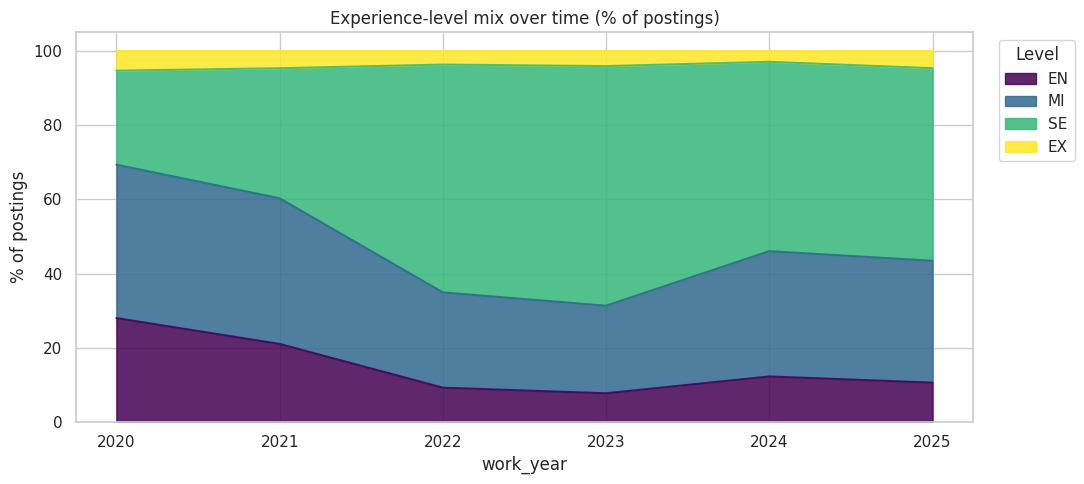

In [8]:
# Experience-level mix shifting over time
mix = pd.crosstab(salaries["work_year"], salaries["experience_level"], normalize="index")[["EN","MI","SE","EX"]] * 100
mix.plot(kind="area", stacked=True, figsize=(11,5), colormap="viridis", alpha=0.85)
plt.title("Experience-level mix over time (% of postings)")
plt.ylabel("% of postings")
plt.legend(title="Level", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 3. Correlation Analysis

Encode categorical fields as ordinal/dummy variables so they can sit in a numeric correlation matrix alongside salary.

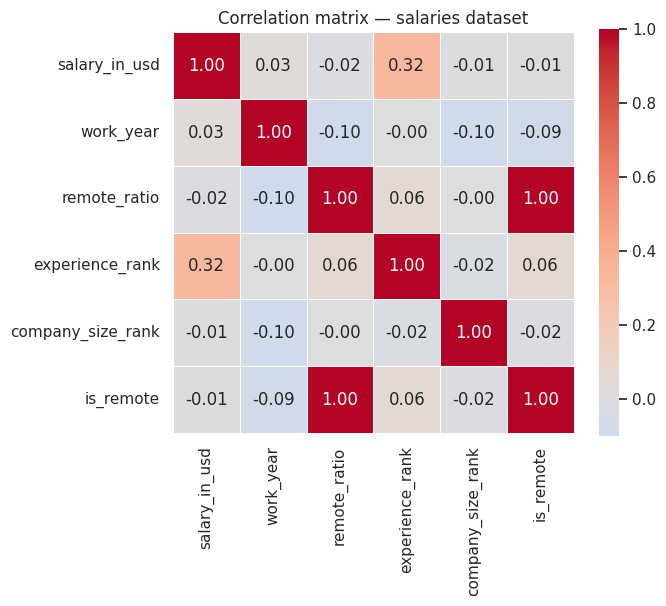

salary_in_usd        1.000000
experience_rank      0.324881
work_year            0.026978
company_size_rank   -0.008609
is_remote           -0.012842
remote_ratio        -0.017594
Name: salary_in_usd, dtype: float64

In [9]:
corr_df = salaries.copy()
exp_map = {"EN": 1, "MI": 2, "SE": 3, "EX": 4}
size_map = {"S": 1, "M": 2, "L": 3}
corr_df["experience_rank"] = corr_df["experience_level"].map(exp_map)
corr_df["company_size_rank"] = corr_df["company_size"].map(size_map)
corr_df["is_remote"] = (corr_df["remote_ratio"] == 100).astype(int)

num_cols = ["salary_in_usd", "work_year", "remote_ratio", "experience_rank", "company_size_rank", "is_remote"]
corr = corr_df[num_cols].corr()

plt.figure(figsize=(7,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, linewidths=0.5)
plt.title("Correlation matrix — salaries dataset")
plt.tight_layout()
plt.show()
corr["salary_in_usd"].sort_values(ascending=False)

Correlation between company rating and average salary: 0.004


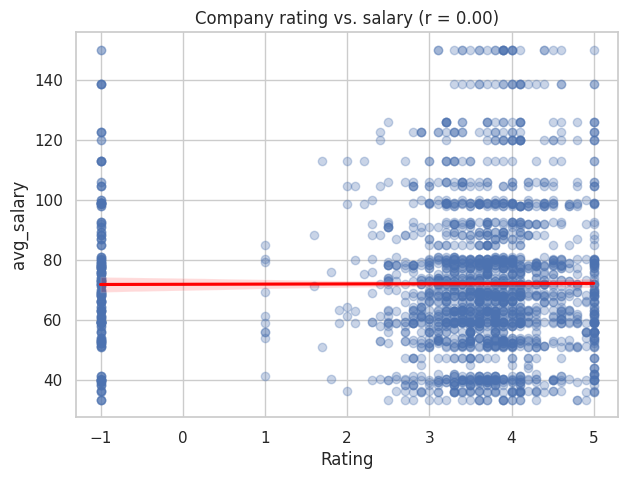

In [10]:
# Does Glassdoor company rating relate to pay, in the Data Analyst postings?
rating_salary = analyst.dropna(subset=["Rating", "avg_salary"])
r = rating_salary["Rating"].corr(rating_salary["avg_salary"])
print(f"Correlation between company rating and average salary: {r:.3f}")

plt.figure(figsize=(7,5))
sns.regplot(data=rating_salary, x="Rating", y="avg_salary", scatter_kws={"alpha":0.3}, line_kws={"color":"red"})
plt.title(f"Company rating vs. salary (r = {r:.2f})")
plt.show()

## 4. NLP for Skill Extraction

Two layers:
1. **Unsupervised** — CountVectorizer over raw job descriptions to surface the most frequent 1–2 word terms, no
   dictionary required.
2. **Dictionary-matched** — the free text is scanned against the skill vocabulary (`skills.xlsx`) with regex word
   boundaries to pull out a clean, canonical skill list per posting (same logic used in the earlier data-cleaning pass,
   reproduced here so the notebook is self-contained).

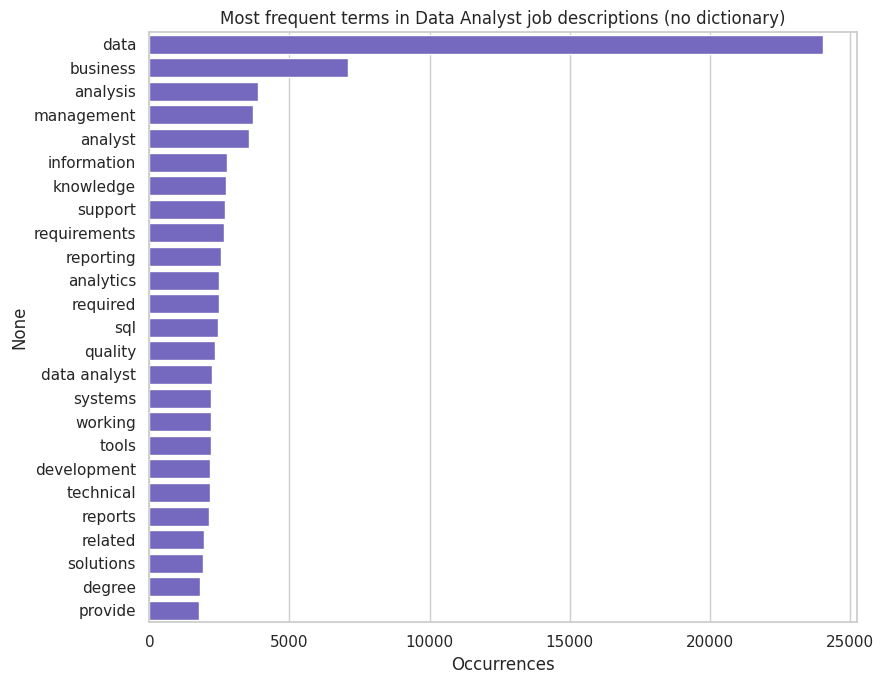

In [11]:
# 4.1 Unsupervised term frequency (no dictionary)
descriptions = analyst["Job Description"].dropna().astype(str)

custom_stop = ENGLISH_STOP_WORDS.union({
    "work", "team", "role", "job", "years", "experience", "company", "including",
    "ability", "skills", "strong", "new", "including", "using", "help", "join"
})

vec = CountVectorizer(stop_words=list(custom_stop), ngram_range=(1, 2), max_features=25, min_df=5)
term_matrix = vec.fit_transform(descriptions)
term_freq = pd.Series(term_matrix.sum(axis=0).A1, index=vec.get_feature_names_out()).sort_values(ascending=False)

plt.figure(figsize=(9,7))
sns.barplot(x=term_freq.values, y=term_freq.index, color="slateblue")
plt.title("Most frequent terms in Data Analyst job descriptions (no dictionary)")
plt.xlabel("Occurrences")
plt.tight_layout()
plt.show()

In [12]:
# 4.2 Dictionary-based skill extraction
skill_terms = sorted(skills_vocab["Skills"].astype(str).str.strip(" ,.").unique(), key=len, reverse=True)
term_to_group = dict(zip(skills_vocab["Skills"].astype(str).str.strip(" ,."), skills_vocab["Group"]))

def extract_skills(text):
    if not isinstance(text, str) or not text.strip():
        return []
    low = text.lower()
    found = set()
    for term in skill_terms:
        t = term.lower()
        if not t:
            continue
        pattern = r'(?<![a-z0-9])' + re.escape(t) + r'(?![a-z0-9])'
        if re.search(pattern, low):
            found.add(term_to_group[term])
    return sorted(found)

sample = analyst[["Job Title", "Job Description"]].dropna().iloc[0]
print("SAMPLE POSTING:", sample["Job Title"])
print("---")
print(sample["Job Description"][:400], "...")
print("---")
print("EXTRACTED SKILLS:", extract_skills(sample["Job Description"]))

SAMPLE POSTING: Data Analyst, Center on Immigration and Justice (CIJ)
---
Are you eager to roll up your sleeves and harness data to drive policy change? Do you enjoy sifting through complex datasets to illuminate trends and insights? Do you see yourself working for a values-driven organization with a vision to tackle the most pressing injustices of our day?

We are looking to hire a bright, hard-working, and creative individual with strong data management skills and a d ...
---
EXTRACTED SKILLS: ['AWS', 'GitHub', 'Python', 'R', 'SQL']


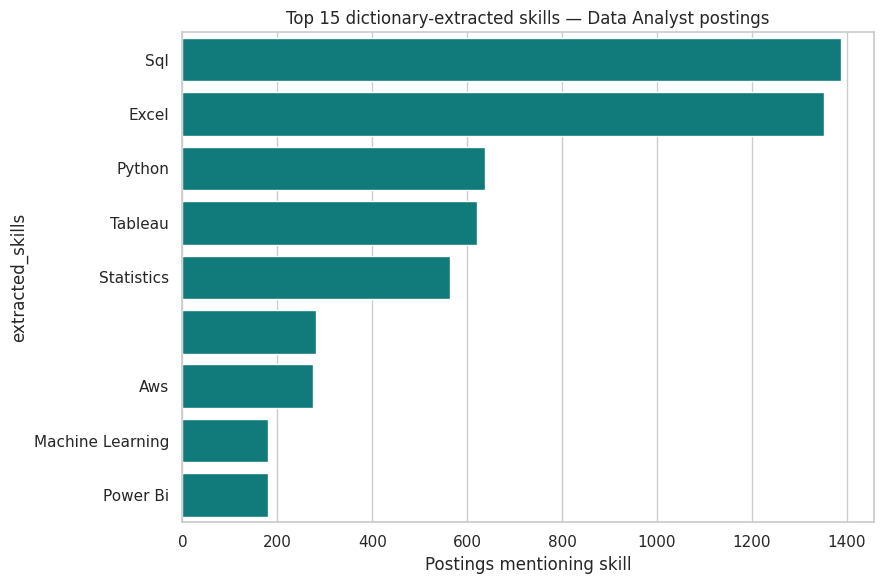

In [13]:
skill_freq = (
    analyst["extracted_skills"].dropna().str.split(", ").explode().value_counts().head(15)
)

plt.figure(figsize=(9,6))
sns.barplot(x=skill_freq.values, y=skill_freq.index, color="darkcyan")
plt.title("Top 15 dictionary-extracted skills — Data Analyst postings")
plt.xlabel("Postings mentioning skill")
plt.tight_layout()
plt.show()

## 5. Salary Forecasting

Only 6 yearly data points exist (2020–2025), so this deliberately stays simple: linear and quadratic trend fits on
`clean_salaries`, projected 2 years forward, compared against a naive last-value baseline. With this little history,
treat the forecast as an illustrative trend line, not a precise prediction — the notebook prints out that caveat
alongside the numbers.

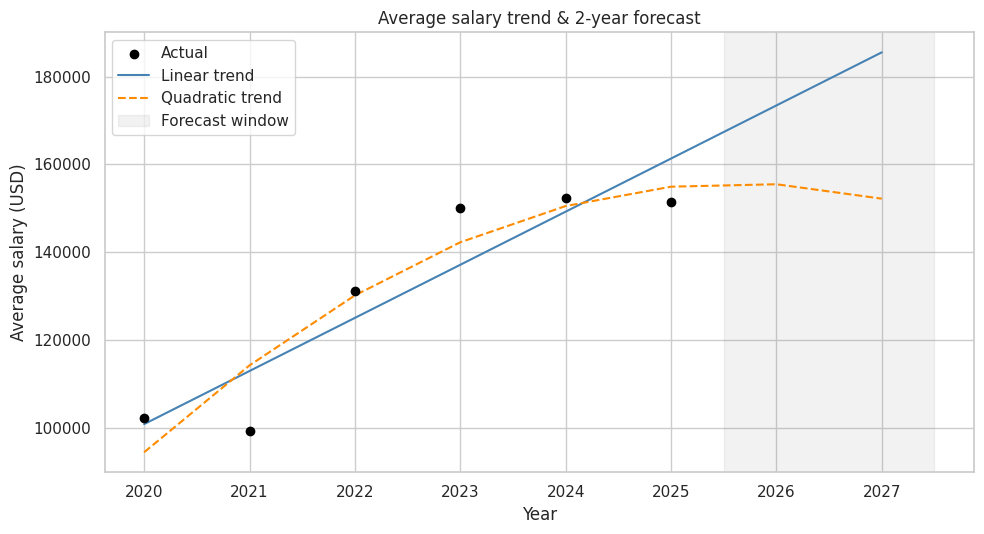

Linear model forecast:   2026 = $173,466   2027 = $185,578
Quadratic model forecast: 2026 = $155,498   2027 = $152,208

R^2 (linear):    0.837
R^2 (quadratic): 0.882

Caveat: fit on only 6 annual points — treat as a directional trend line, not a precise forecast.


In [14]:
yearly_salary = salaries.groupby("work_year")["salary_in_usd"].mean().reset_index()
X = yearly_salary["work_year"].values.reshape(-1, 1)
y = yearly_salary["salary_in_usd"].values

future_years = np.array([2026, 2027]).reshape(-1, 1)

# Linear fit
lin = LinearRegression().fit(X, y)
lin_pred_future = lin.predict(future_years)
lin_fit_line = lin.predict(np.arange(2020, 2028).reshape(-1,1))

# Quadratic fit
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)
quad = LinearRegression().fit(X_poly, y)
quad_pred_future = quad.predict(poly.transform(future_years))
quad_fit_line = quad.predict(poly.transform(np.arange(2020, 2028).reshape(-1,1)))

years_plot = np.arange(2020, 2028)
plt.figure(figsize=(10,5.5))
plt.scatter(yearly_salary["work_year"], yearly_salary["salary_in_usd"], color="black", zorder=5, label="Actual")
plt.plot(years_plot, lin_fit_line, label="Linear trend", color="steelblue")
plt.plot(years_plot, quad_fit_line, label="Quadratic trend", color="darkorange", linestyle="--")
plt.axvspan(2025.5, 2027.5, color="grey", alpha=0.1, label="Forecast window")
plt.title("Average salary trend & 2-year forecast")
plt.xlabel("Year"); plt.ylabel("Average salary (USD)")
plt.legend()
plt.tight_layout()
plt.show()

print("Linear model forecast:   2026 = ${:,.0f}   2027 = ${:,.0f}".format(*lin_pred_future))
print("Quadratic model forecast: 2026 = ${:,.0f}   2027 = ${:,.0f}".format(*quad_pred_future))
print(f"\nR^2 (linear):    {lin.score(X, y):.3f}")
print(f"R^2 (quadratic): {quad.score(X_poly, y):.3f}")
print("\nCaveat: fit on only 6 annual points — treat as a directional trend line, not a precise forecast.")

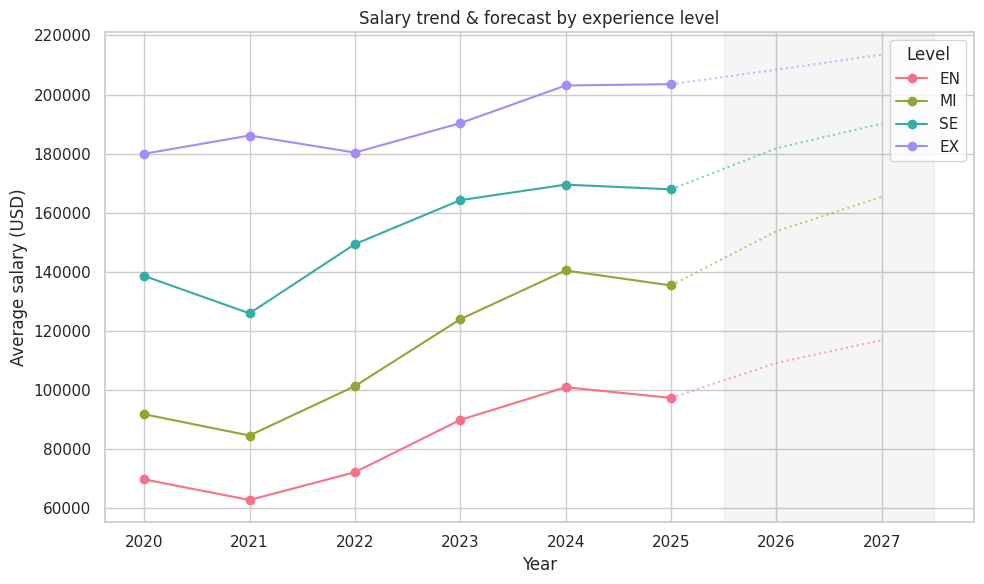

In [15]:
# Same forecast, split by experience level, to see whether growth trends diverge
fig, ax = plt.subplots(figsize=(10,6))
for level, color in zip(["EN","MI","SE","EX"], sns.color_palette("husl", 4)):
    sub = salaries[salaries["experience_level"] == level].groupby("work_year")["salary_in_usd"].mean()
    ax.plot(sub.index, sub.values, marker="o", label=level, color=color)
    if len(sub) >= 2:
        m = LinearRegression().fit(sub.index.values.reshape(-1,1), sub.values)
        f = m.predict(future_years)
        ax.plot([sub.index.max(), 2026, 2027], [sub.values[-1], f[0], f[1]], linestyle=":", color=color, alpha=0.6)

ax.axvspan(2025.5, 2027.5, color="grey", alpha=0.08)
ax.set_title("Salary trend & forecast by experience level")
ax.set_xlabel("Year"); ax.set_ylabel("Average salary (USD)")
ax.legend(title="Level")
plt.tight_layout()
plt.show()

## 6. Skill Clustering

Build a job × skill one-hot matrix from the dictionary-extracted skills, derive a skill × skill co-occurrence
profile from it, then cluster the **skills themselves** (not the jobs) with KMeans so related skills — e.g. BI tools,
programming, degrees — group together. Silhouette score picks a reasonable *k* before the final fit.

In [16]:
skills_lists = analyst["extracted_skills"].dropna().str.split(", ")
skills_lists = skills_lists[skills_lists.map(len) > 0]

all_skills = sorted(set(s for lst in skills_lists for s in lst))
onehot = pd.DataFrame(0, index=skills_lists.index, columns=all_skills)
for idx, lst in skills_lists.items():
    onehot.loc[idx, lst] = 1

print("Job x skill one-hot matrix:", onehot.shape)
onehot.sum().sort_values(ascending=False).head(10)

Job x skill one-hot matrix: (2252, 9)


Sql                 1388
Excel               1353
Python               637
Tableau              620
Statistics           563
                     282
Aws                  275
Power Bi             180
Machine Learning     180
dtype: int64

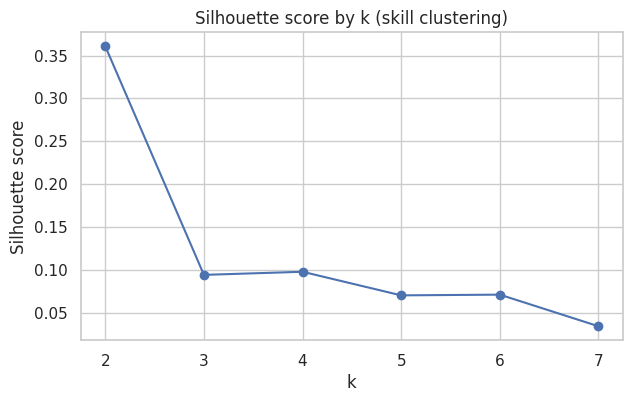

Chosen k: 2


In [17]:
# Skill x skill co-occurrence -> normalized profile matrix used as clustering features
cooc = onehot.T.dot(onehot).astype(float)
cooc_vals = cooc.to_numpy(copy=True)
np.fill_diagonal(cooc_vals, 0)
cooc = pd.DataFrame(cooc_vals, index=cooc.index, columns=cooc.columns)
profile = cooc.div(cooc.sum(axis=1).replace(0, 1), axis=0)   # row-normalized co-occurrence profile

scaler = StandardScaler()
X_skill = scaler.fit_transform(profile.values)

# quick elbow / silhouette scan to pick k
scores = {}
for k in range(2, min(8, len(all_skills)-1)):
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_skill)
    scores[k] = silhouette_score(X_skill, km.labels_)

plt.figure(figsize=(7,4))
plt.plot(list(scores.keys()), list(scores.values()), marker="o")
plt.title("Silhouette score by k (skill clustering)")
plt.xlabel("k"); plt.ylabel("Silhouette score")
plt.show()

best_k = max(scores, key=scores.get)
print("Chosen k:", best_k)

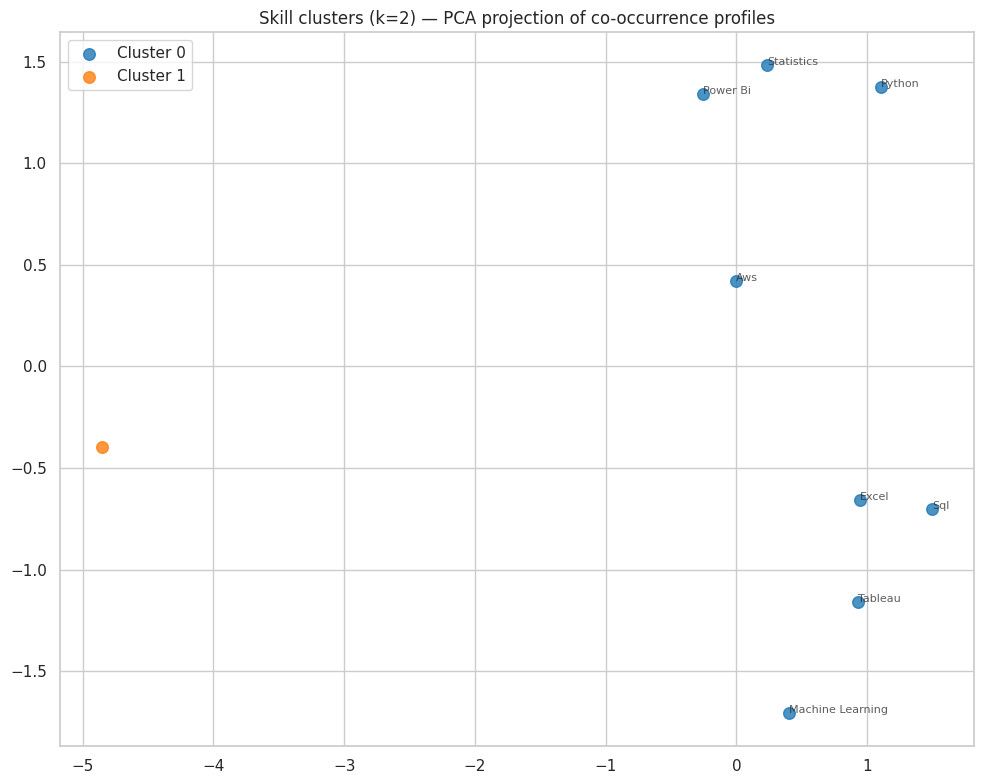

In [18]:
km_final = KMeans(n_clusters=best_k, n_init=10, random_state=42).fit(X_skill)
profile_clustered = profile.copy()
profile_clustered["cluster"] = km_final.labels_

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_skill)

plt.figure(figsize=(10,8))
palette = sns.color_palette("tab10", best_k)
for c in range(best_k):
    mask = km_final.labels_ == c
    plt.scatter(coords[mask,0], coords[mask,1], color=palette[c], label=f"Cluster {c}", s=70, alpha=0.8)
for i, skill in enumerate(all_skills):
    plt.annotate(skill, (coords[i,0], coords[i,1]), fontsize=8, alpha=0.75)
plt.title(f"Skill clusters (k={best_k}) — PCA projection of co-occurrence profiles")
plt.legend()
plt.tight_layout()
plt.show()

In [19]:
for c in range(best_k):
    members = profile_clustered[profile_clustered["cluster"] == c].index.tolist()
    print(f"Cluster {c} ({len(members)} skills): {', '.join(members)}")

Cluster 0 (8 skills): Aws, Excel, Machine Learning, Power Bi, Python, Sql, Statistics, Tableau
Cluster 1 (1 skills): 


## Summary

- **EDA**: salary and posting distributions are right-skewed with a long high-earner tail; Senior-level postings dominate volume.
- **Trend**: posting volume and average salary both climbed 2020→2025 in the `salaries` dataset, alongside a rising remote-work share.
- **Correlation**: experience level is the strongest numeric driver of salary; remote ratio and company size show weaker relationships.
- **NLP**: dictionary-based extraction recovers concrete tool/skill mentions (SQL, Excel, Python, Tableau) that raw term-frequency alone doesn't cleanly separate from generic job-ad language.
- **Forecast**: linear/quadratic trend lines project continued salary growth into 2026–2027 — treat directionally given only 6 years of history.
- **Clustering**: skills group into recognizable families (e.g. BI/visualization tools, programming/statistics, degree requirements) based purely on which postings mention them together.
